<a href="https://colab.research.google.com/github/rahul1234500/python/blob/main/ml/House_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

In [ ]:
from sklearn.datasets import fetch_california_housing

data = fetch_california_housing()
df = pd.DataFrame(data.data , columns=data.feature_names)
df['price'] = data.target
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [ ]:
df.isnull().sum()

df = df.dropna()

df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [ ]:
X = df[['MedInc' , 'HouseAge' , 'AveRooms' , 'Population']]
y = df['price']


In [ ]:
X_train , X_test , y_train , y_test = train_test_split(
    X, y,test_size=0.2, random_state=42
)

In [ ]:
model = LinearRegression()
model.fit(X_train , y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
print("MAE:", metrics.mean_absolute_error(y_test, y_pred))
print("MSE:", metrics.mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

MAE: 0.6024695935335578
MSE: 0.6577995678634072
RMSE: 0.8110484374335526


In [ ]:
sample = [[8.5,10,6,300]] # example values
prediction = model.predict(sample)
print('Predicted Price: ', prediction)

Predicted Price:  [3.75957275]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [13]:
from google.colab import files
uploaded = files.upload()

Saving AmesHousing.csv to AmesHousing.csv
Saving target.csv to target.csv
Saving test.csv to test.csv
Saving train.csv to train.csv


In [14]:
import pandas as pd

df = pd.read_csv("train.csv")  # filename from kaggle
df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,534,531363010,20,RL,80.0,9605,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2009,WD,Normal,159000
1,803,906203120,20,RL,90.0,14684,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,6,2009,WD,Normal,271900
2,956,916176030,20,RL,NaN,14375,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,1,2009,COD,Abnorml,137500
3,460,528180130,120,RL,48.0,6472,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2009,WD,Normal,248500
4,487,528290030,80,RL,61.0,9734,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2009,WD,Normal,167000


In [16]:
df['TotalArea'] = df['Gr Liv Area'] + df['Total Bsmt SF']

In [17]:
from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

In [18]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [19]:
from sklearn.metrics import mean_squared_error

print("Linear Regression:", mean_squared_error(y_test, y_pred))
print("Decision Tree:", mean_squared_error(y_test, y_pred_dt))
print("Random Forest:", mean_squared_error(y_test, y_pred_rf))

Linear Regression: 0.6577995678634072
Decision Tree: 1.0563350522871608
Random Forest: 0.5738292626450195


In [20]:
df.fillna(0, inplace=True)

In [21]:
df = pd.get_dummies(df)

In [25]:
# Total area
df['TotalArea'] = df['Gr Liv Area'] + df['Total Bsmt SF']

# Total bathrooms
df['TotalBathrooms'] = df['Full Bath'] + (0.5 * df['Half Bath'])

# Total porch area
df['TotalPorch'] = df['Open Porch SF'] + df['Enclosed Porch'] + df['3Ssn Porch'] + df['Screen Porch']

In [29]:
df['Over all Score'] = df['Overall Qual'] * df['Overall Cond']

In [34]:
df['HouseAge'] = df['Yr Sold'] - df['Year Built']
df['Remodel Age'] = df['Yr Sold'] - df['Year Remod/Add']

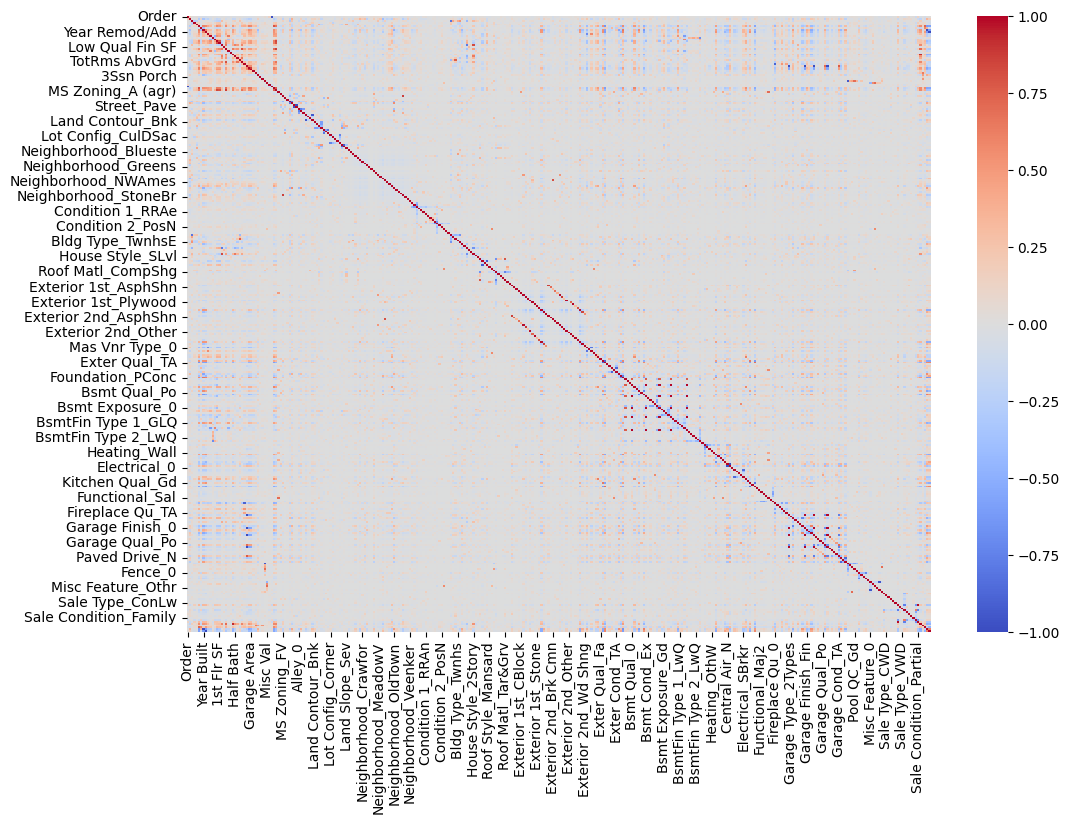

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.show()

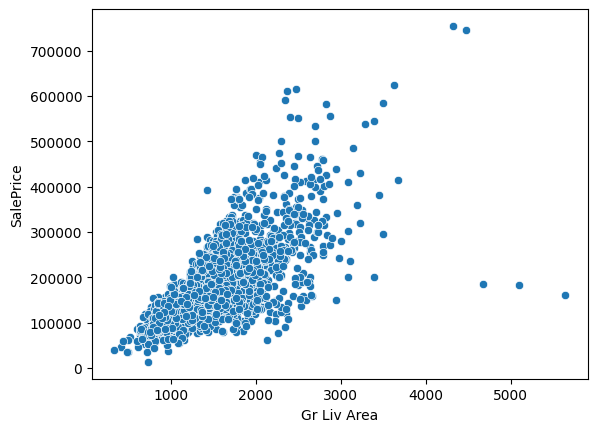

In [40]:
sns.scatterplot(x=df['Gr Liv Area'], y=df['SalePrice'])
plt.show()

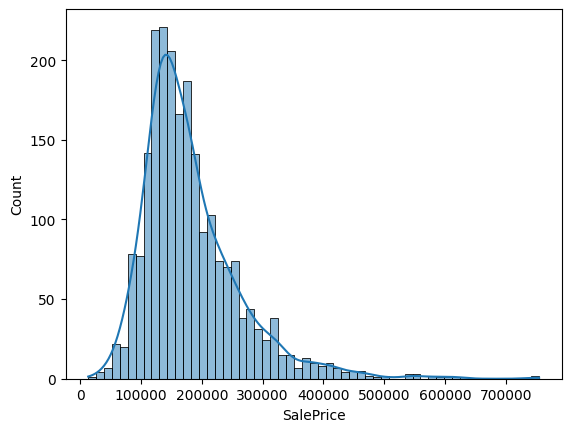

In [41]:
sns.histplot(df['SalePrice'], kde=True)
plt.show()